In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
cv_results <- read_csv(
    "ml_algorithms/results/svm/svm_paper_cv.csv"
)

New names:
• `` -> `...1`
Rows: 7 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): ...1
dbl (4): Cef, Cip, Mer, Tob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
cv_results

...1,Cef,Cip,Mer,Tob
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
genexp,0.7910599,0.8119587,0.8516446,0.8860183
genexp+snps,0.7395416,0.8266246,0.8708466,0.8580686
gpa,0.6689689,0.7872591,0.8679951,0.9047365
genexp+gpa,0.7696583,0.8119587,0.8733362,0.8887150
genexp+gpa+snps,0.7395416,0.8006709,0.8648108,0.8698525
gpa+snps,0.6868546,0.8863798,0.8675371,0.8974943
snps,0.6376601,0.8898318,0.5803940,0.8844709


## Analyze data on different data type combinations from the paper

In [4]:
performances <- read_csv(
    "./other_data/perf_all.csv"
)

Rows: 280 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): drug, cv_mode, mode
dbl (15): pos_recall, pos_recall_std, neg_recall, neg_recall_std, precision,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [36]:
head(performances)

drug,pos_recall,pos_recall_std,neg_recall,neg_recall_std,precision,precision_std,npv,npv_std,balanced_accuracy,balanced_accuracy_std,F1-score_micro,F1-score_micro_std,F1-score_macro,F1-score_macro_std,AUC,cv_mode,mode
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Meropenem,0.826,0.109,0.843,0.170,0.920,0.081,0.688,0.118,0.834,0.100,0.870,0.085,0.814,0.090,0.877,block_cv,expr
Tobramycin,0.647,0.390,0.852,0.175,0.667,0.361,0.841,0.210,0.750,0.129,0.657,0.306,0.752,0.112,0.823,block_cv,expr
Ciprofloxacin,0.679,0.266,0.859,0.123,0.857,0.213,0.683,0.155,0.769,0.156,0.758,0.229,0.760,0.164,0.798,block_cv,expr
Ceftazidim,0.782,0.210,0.815,0.240,0.806,0.129,0.791,0.233,0.798,0.126,0.794,0.147,0.798,0.129,0.862,block_cv,expr
Meropenem,0.759,0.140,0.820,0.210,0.902,0.102,0.608,0.173,0.790,0.129,0.825,0.099,0.762,0.120,0.883,block_cv,expr_snps
Tobramycin,0.608,0.408,0.901,0.310,0.738,0.413,0.834,0.318,0.755,0.181,0.667,0.358,0.767,0.209,0.803,block_cv,expr_snps


In [5]:
performances_filtered <- performances %>%
    filter(cv_mode == "standard_cv") %>%
    filter(drug == "Tobramycin") %>%
    select(c("drug", "F1-score_macro", "F1-score_macro_std", "mode") )
colnames(performances_filtered) <- c("drug", "F1_score_macro", "F1_score_macro_std", "mode")

In [6]:
performances_filtered %>%
    group_by(mode) %>%
    summarise(F1_score = mean(F1_score_macro))

mode,F1_score
<chr>,<dbl>
expr,0.8800
expr_snps,0.8830
gpa,0.9008
gpa_expr,0.9162
gpa_expr_snps,0.9010
gpa_snps,0.8926
snps,0.8806


# Percentages of susceptible and resistent for each drug

In [6]:
library(tidyverse)
classes <- read_csv(
    "transformed_data/targets/targets.csv"
)

Rows: 414 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Strain
dbl (5): Tob, Cef, Cip, Mer, Index

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
head(Mer_S_vs_R)

Mer,count
<dbl>,<int>
0,110
1,244


In [7]:
Cef_S_vs_R <- classes %>%
    drop_na(Cef) %>%
    group_by(Cef) %>%
    summarize(count = n())

Cip_S_vs_R <- classes %>%
    drop_na(Cip) %>%
    group_by(Cip) %>%
    summarize(count = n())

Mer_S_vs_R <- classes %>%
    drop_na(Mer) %>%
    group_by(Mer) %>%
    summarize(count = n())

Tob_S_vs_R <- classes %>%
    drop_na(Tob) %>%
    group_by(Tob) %>%
    summarize(count = n())


# Logistic regression

Remember the definitions:
* precision s: ts / ts + fs
* recall s: ts / ts + fr
* precision r: tr / tr + fr
* recall r: tr / tr + fs

Comments: if C = 1, too many features are used (between 15000 and 22000 with coefficients higher than 0.01), so data risk to be overfitted. Better decrease C to have a stronger regularization. Same happens with 0.1, because l2 regularization is the Ridge regularization, which is useless in these cases (does not avoid overfit, it seems, but you should check using the performance on the training set if you want to write in the final paper).

The Lasso regression with the 'saga' solver seems to take too much time. But we can use the liblinear solver.

In [6]:
library(tidyverse)
log_reg_scores <- read_csv(
    "ml_algorithms/results/logistic_regression/log_reg.csv"
)

New names:
• `` -> `...1`
Rows: 12 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): drug, features
dbl (7): ...1, best C, precision_s, precision_r, recall_s, recall_r, accuracy

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [7]:
log_reg_scores

...1,drug,features,best C,precision_s,precision_r,recall_s,recall_r,accuracy
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,Cef,genexp,3.593814e-01,0.7428571,0.7500000,0.7647059,0.7272727,0.7462687
1,Cef,gpa,3.593814e-01,0.7027027,0.7333333,0.7647059,0.6666667,0.7164179
2,Cef,snps,3.593814e-01,0.5405405,0.5333333,0.5882353,0.4848485,0.5373134
3,Cip,genexp,1.000000e+04,0.7222222,0.8333333,0.8125000,0.7500000,0.7777778
4,Cip,gpa,1.000000e+04,0.7058824,0.7894737,0.7500000,0.7500000,0.7500000
5,Cip,snps,2.782559e+00,0.7812500,0.8250000,0.7812500,0.8250000,0.8055556
6,Mer,genexp,3.593814e-01,0.8333333,0.8679245,0.6818182,0.9387755,0.8591549
7,Mer,gpa,3.593814e-01,0.8823529,0.8703704,0.6818182,0.9591837,0.8732394
8,Mer,snps,2.154435e+01,0.3750000,0.7090909,0.2727273,0.7959184,0.6338028


In [8]:
log_reg_coefficients <- read_csv(
    "ml_algorithms/results/logistic_regression/log_reg_coefficients.csv"
)

New names:
• `` -> `...1`
Rows: 5 Columns: 94268
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (94267): PA0263.1,tRNA-Arg, PA0296-PA0297,P1, PA0826.2,ssrA, PA0836.1,P5...
dbl     (1): ...1

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [9]:
log_reg_coefficients <- as_tibble(t(log_reg_coefficients), rownames = 'Features')
colnames(log_reg_coefficients) <- c("Features", "Feature_type", "Cef", "Cip", "Mer", "Tob")
log_reg_coefficients <- log_reg_coefficients %>%
    slice(-1)

Warning message:
“The `x` argument of `as_tibble.matrix()` must have unique column names if
`.name_repair` is omitted as of tibble 2.0.0.
ℹ Using compatibility `.name_repair`.”


In [10]:
log_features_kept <- log_reg_coefficients %>%
    select(Features, Feature_type, Tob) %>%
    filter(Tob != '0.0') #numbers are represented as strings
nrow(log_features_kept)

[1] 452

In [11]:
log_features_kept %>%
    group_by(Feature_type) %>%
    summarize(n = n())

Feature_type,n
<chr>,<int>
genexp,83
gpa,42
snps,327


## Logistic regression with feature selection

Now we select only the features used in the Lasso regression (those with coefficients different from 0), and apply again a logistic regression, using this time the combination of two or three different types of features. The logistic regression uses a Lasso regularization again, selecting again the C parameter through cross-validation.

We don't have overfitting as before (number of features with non zero coefficients is lower than the number of training samples), but performances are in all cases decreased with respect to the use of the best data type for each drug (genexp for Cef and Tob, gpa for Mer and snps for Cip). Using all the three data types gives the best performances for combinations of types, but performances are still lower than those obtained by using the best single type of feature.

So, logistic regression can lead to good results, especially for Tobramycin, but it is not able to integrate efficiently different types of data.

In [12]:
library(tidyverse)
log_reg_relevant_features <- read_csv(
    "ml_algorithms/results/logistic_regression/log_reg_relevant_features.csv"
)

New names:
• `` -> `...1`
Rows: 16 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): drug, features
dbl (9): ...1, best C, train samples, features used, precision_s, precision_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [13]:
log_reg_relevant_features

...1,drug,features,best C,train samples,features used,precision_s,precision_r,recall_s,recall_r,accuracy
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,Cef,genexp+snps,10000.00,267,116,0.6944444,0.7096774,0.7352941,0.6666667,0.7014925
1,Cef,genexp+gpa,10000.00,267,89,0.7500000,0.7142857,0.7058824,0.7575758,0.7313433
2,Cef,genexp+gpa+snps,10000.00,267,115,0.7352941,0.7272727,0.7352941,0.7272727,0.7313433
3,Cef,gpa+snps,1291.55,267,100,0.5757576,0.5588235,0.5588235,0.5757576,0.5671642
4,Cip,genexp+snps,10000.00,286,244,0.7575758,0.8205128,0.7812500,0.8000000,0.7916667
5,Cip,genexp+gpa,10000.00,286,386,0.7142857,0.8108108,0.7812500,0.7500000,0.7638889
6,Cip,genexp+gpa+snps,10000.00,286,296,0.7352941,0.8157895,0.7812500,0.7750000,0.7777778
7,Cip,gpa+snps,10000.00,286,174,0.7428571,0.8378378,0.8125000,0.7750000,0.7916667
8,Mer,genexp+snps,10000.00,283,109,0.8750000,0.8545455,0.6363636,0.9591837,0.8591549


# PCA separation

Try to separate the two classes (susceptible and resistent) using PCA, by keeping only the two principal components with the highest explained variance.

In [3]:
library(tidyverse)
pca_cef <- read_csv(
    "ml_algorithms/results/pca/pca_Cef.csv"
)
pca_cip <- read_csv(
    "ml_algorithms/results/pca/pca_Cip.csv"
)
pca_mer <- read_csv(
    "ml_algorithms/results/pca/pca_Mer.csv"
)
pca_tob <- read_csv(
    "ml_algorithms/results/pca/pca_Tob.csv"
)

New names:
• `` -> `...1`
Rows: 334 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Strain
dbl (9): ...1, Cef, Index, genexp_1, genexp_2, gpa_1, gpa_2, snps_1, snps_2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 358 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Strain
dbl (9): ...1, Cip, Index, genexp_1, genexp_2, gpa_1, gpa_2, snps_1, snps_2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 354 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Strain
dbl (9): ...1, Mer, Index, genexp_1, genexp_2, gpa_1, gpa_

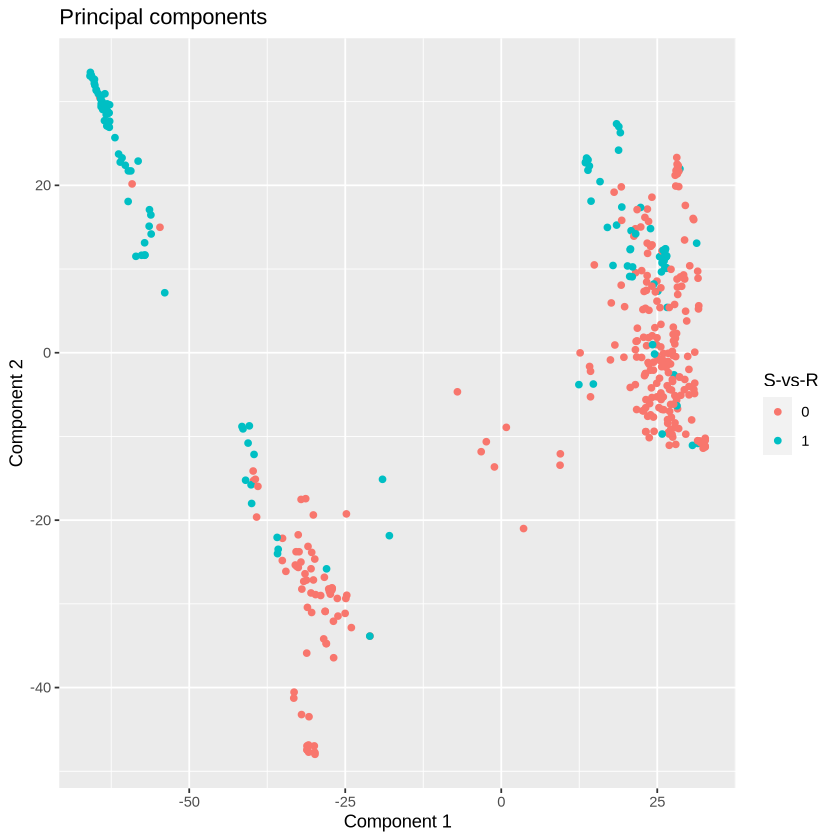

In [4]:
ggplot(data = pca_tob, aes(x = snps_1, y = snps_2)) +
    geom_point(aes(color = as.character(Tob))) +
    labs(title = "Principal components", x = "Component 1", y = "Component 2", color = "S-vs-R")

While for gene expression points seem to be mixed, for gpa and snps we can see the formation of three clusters. They are probably linked to phylogenetic tree of bacteria, but as it is clear this does not influence the division between susceptible and resistent. So clustering methods are not really useful to separate susceptible and resistent samples: it is more likely that clustering separates different phylogenetic trees instead.

# Linear discriminant analysis

The classification performaces are incredibly higher for Tobramycin than for all the other drugs. Interesting to notice that, even if in the table of number of S-vs-R samples in some cases the number of classified samples in one class is close to the real one, some of those samples are wrongly classified, so the classification performances are worse.

So, in general it is better to look at the score table. The count table is useful only to see if there are stupid classifiers (classifiers that put all the samples in one class and no one in the other).

In [1]:
library(tidyverse)
lda_scores <- read_csv(
    "ml_algorithms/results/lda/lda_scores.csv"
)

lda_counts <- read_csv(
    "ml_algorithms/results/lda/lda_counts.csv"
)

lda_scores
lda_counts

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
New names:
• `` -> `...1`
Rows: 28 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): drug, features
dbl (6): ...1, precision_s, precision_r, recall_s, recall_r, accuracy

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 28 Columns: 8
── Column specification ───────────────

...1,drug,features,precision_s,precision_r,recall_s,recall_r,accuracy
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,Cef,genexp,0.6571429,0.6562500,0.6764706,0.6363636,0.6567164
1,Cef,genexp+snps,0.6785714,0.6153846,0.5588235,0.7272727,0.6417910
2,Cef,gpa,0.6585366,0.7307692,0.7941176,0.5757576,0.6865672
3,Cef,genexp+gpa,0.6744186,0.7916667,0.8529412,0.5757576,0.7164179
4,Cef,genexp+gpa+snps,0.6666667,0.6470588,0.6470588,0.6666667,0.6567164
5,Cef,gpa+snps,0.6969697,0.6764706,0.6764706,0.6969697,0.6865672
6,Cef,snps,0.6875000,0.6571429,0.6470588,0.6969697,0.6716418
7,Cip,genexp,0.6857143,0.7837838,0.7500000,0.7250000,0.7361111
8,Cip,genexp+snps,0.6486486,0.7714286,0.7500000,0.6750000,0.7083333


...1,drug,features,test samples,predicted_s,real_s,predicted_r,real_r
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,Cef,genexp,67,35,34,32,33
1,Cef,genexp+snps,67,28,34,39,33
2,Cef,gpa,67,41,34,26,33
3,Cef,genexp+gpa,67,43,34,24,33
4,Cef,genexp+gpa+snps,67,33,34,34,33
5,Cef,gpa+snps,67,33,34,34,33
6,Cef,snps,67,32,34,35,33
7,Cip,genexp,72,35,32,37,40
8,Cip,genexp+snps,72,37,32,35,40


# Quadratic discriminat analysis with dimensionality reduction

It is a horrible classifier. Tends to classify all samples in just one class.

In [ ]:
library(tidyverse)
qda_scores <- read_csv(
    "ml_algorithms/results/lda/qda_scores.csv"
)

qda_counts <- read_csv(
    "ml_algorithms/results/lda/qda_counts.csv"
)

qda_scores
qda_counts

New names:
• `` -> `...1`
Rows: 28 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): drug, features
dbl (6): ...1, precision_s, precision_r, recall_s, recall_r, accuracy

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 28 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): drug, features
dbl (6): ...1, test samples, predicted_s, real_s, predicted_r, real_r

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


...1,drug,features,precision_s,precision_r,recall_s,recall_r,accuracy
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,Cef,genexp,0.9000000,0.5614035,0.26470588,0.9696970,0.6119403
1,Cef,genexp+snps,0.6470588,0.5400000,0.32352941,0.8181818,0.5671642
2,Cef,gpa,0.8333333,0.5245902,0.14705882,0.9696970,0.5522388
3,Cef,genexp+gpa,0.8571429,0.5333333,0.17647059,0.9696970,0.5671642
4,Cef,genexp+gpa+snps,0.7142857,0.5471698,0.29411765,0.8787879,0.5820896
5,Cef,gpa+snps,0.6052632,0.6206897,0.67647059,0.5454545,0.6119403
6,Cef,snps,0.5245902,0.6666667,0.94117647,0.1212121,0.5373134
7,Cip,genexp,0.5000000,0.5571429,0.03125000,0.9750000,0.5555556
8,Cip,genexp+snps,0.2500000,0.5312500,0.06250000,0.8500000,0.5000000


...1,drug,features,test samples,predicted_s,real_s,predicted_r,real_r
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,Cef,genexp,67,10,34,57,33
1,Cef,genexp+snps,67,17,34,50,33
2,Cef,gpa,67,6,34,61,33
3,Cef,genexp+gpa,67,7,34,60,33
4,Cef,genexp+gpa+snps,67,14,34,53,33
5,Cef,gpa+snps,67,38,34,29,33
6,Cef,snps,67,61,34,6,33
7,Cip,genexp,72,2,32,70,40
8,Cip,genexp+snps,72,8,32,64,40
